---
title: Splits Testing
author: Fedor Pavlov
date: 2026-03-23
format:
  html:
    code-fold: true
    code-summary: "Show the code"
  pdf:
    code-overflow: wrap
    echo: false
    output: true
---

A clone of Fedor Pavlov's code on `splits_testing.py` (deprecated, check previous versions of the branch), made by Andrei Akopian for some testing and image exports.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic
from sklearn.ensemble import RandomForestRegressor

## Loading the Data

In [5]:
LAB_DATA = "../../../data/useful_columns_data.csv"
ATMO_DATA = "../../../data/isprs_26_only_vza_rows.csv"

In [6]:
#getting the data to train on
file = pd.read_csv(LAB_DATA)
#getting y's
y = []
for i in range(len(file["Spectra"])):
    y.append([file.loc[i,"npv_fraction"], file.loc[i,"soil_fraction"]])  # use for atmo data
    # y.append([file.loc[i,"gv_fraction"], file.loc[i,"npv_fraction"], file.loc[i,"soil_fraction"]]) # use for lab data

#getting x's
x = []
for i in range(len(file["Spectra"])):
    newAr = []
    for j in range(900,1700,10):
        newAr.append(file.loc[i,str(j)])
    x.append(newAr)
print("number of rows:", len(x))

number of rows: 1723


## Performing the Splits

In [7]:
#spliting the data
def k_split_dataset(X: int, Y: int, train_size_percentage: int) -> list[list[list]]:
    
    kfold = KFold(n_splits=train_size_percentage, shuffle= True, random_state=42)

    ids = range(len(X))
    train_ids = np.array([])
    test_ids = np.array([])
    data = []
    for train, test  in kfold.split(ids):
        train_ids = np.array([])
        test_ids = np.array([])
        x_train = []
        x_test = [] 
        y_train = []  
        y_test = []
        train_ids = np.append(train,train_ids)
        test_ids = np.append(test,test_ids)
        for i in train_ids.astype(int):

            x_train.append(x[i])
            y_train.append(y[i])
        for i in test_ids.astype(int):
            x_test.append(x[i])
            y_test.append(y[i])
        data.append([x_train, x_test, y_train, y_test])
    return data

def get_all_splits(first: int, last: int) -> list:
    ar = []
    for k in range(first, last):
        ar.append(k_split_dataset(x,y,k))
    return ar

def find_the_most_optimal_k_splits(all_splits: list[int]) -> list[float]:
    r2s = []
    splitnum = 2
    for i in all_splits:
        bestr2 = -1
        bestrmse = -1
        best_y_test = []
        best_y_predict = []
        for j in i:
                #splitting the dataset
            X_train, X_test, y_train, y_test = j[0], j[1], j[2], j[3]
                #choosing regression type and training
            regr = RandomForestRegressor(random_state=42)
            regr.fit(X_train, y_train)
            y_predict = regr.predict(X_test)
                #getting results
            r2 = r2_score(y_test,y_predict)
            if r2> bestr2:
                bestr2 = r2
                best_y_test = y_test
                best_y_predict = y_predict
            print(f"train_size: {str(round(splitnum/len(all_splits), 2))}, r2: {str(r2)}")
        # print(len(X_train), len(X_test))
        r2s.append(bestr2)
        splitnum+=1
    return r2s

def find_the_most_optimal_randomsplit() -> list[float]:
    r2s = []
    for i in range(10,100,5):
        X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=1-i/100, train_size=i/100, random_state=42)
        regr = RandomForestRegressor(random_state=42)
        regr.fit(X_train, y_train)
        y_predict = regr.predict(X_test)
        rmse = root_mean_squared_error(y_test, y_predict)
        r2 = r2_score(y_test,y_predict)
        r2s.append(r2)
        print("train_size: "+str(i)+"%, r2: "+str(r2)+", rmse: "+str(rmse))
    return r2s

In [8]:
#orig_scores = cross_validation_scores(x,y,len(x)//10)
all_splits = get_all_splits(2, 20)

## Visualization

In [9]:
def create_r2s_plot(r2s: list[float]) -> None:
    """
    Create a graph of r^2s vs split size.
    """
    plt.rcParams["font.family"] = "Times New Roman"
    csfont = {'fontname':'Times New Roman'}
    plt.figure(figsize=(3, 5))  # change plot dimensions here
    plt.plot(range(10,100,5),r2s)
    plt.title("R^2 vs Train Size", **csfont)
    plt.xlabel("Train Size (%)", **csfont)
    plt.ylabel("R^2", **csfont)
    plt.xticks(range(0,100+1, 10))
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("splits_testing.svg", format='svg')
    plt.show()

In [ ]:
# takes ~10 mintues to run
r2s = find_the_most_optimal_k_splits(all_splits)
create_r2s_plot(r2s)

train_size: 10%, r2: 0.3972412552264723, rmse: 0.23898711157473482
train_size: 15%, r2: 0.4879281151736435, rmse: 0.22044358344662532
train_size: 20%, r2: 0.4988489060333696, rmse: 0.21906942173590538
train_size: 25%, r2: 0.5143578985504567, rmse: 0.21642792544556172
train_size: 30%, r2: 0.5563838072637233, rmse: 0.2075298376128426
train_size: 35%, r2: 0.5654477080174038, rmse: 0.20556122232748353
train_size: 40%, r2: 0.5694291527645781, rmse: 0.2057915371938831
train_size: 45%, r2: 0.596666206332477, rmse: 0.19870589983112777
train_size: 50%, r2: 0.6229902193819254, rmse: 0.1922499865117623
train_size: 55%, r2: 0.6264114208225213, rmse: 0.19184035764263735
train_size: 60%, r2: 0.6483762624723388, rmse: 0.18692368477764376
train_size: 65%, r2: 0.6535409031323293, rmse: 0.18557116036620858
train_size: 70%, r2: 0.6711182028306356, rmse: 0.17966415391095297
train_size: 75%, r2: 0.6696802053845101, rmse: 0.18088938776347907
train_size: 80%, r2: 0.6761211814569267, rmse: 0.1797546905444492


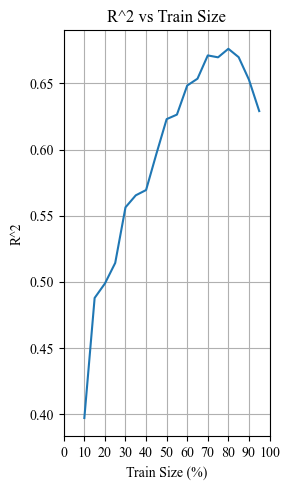

In [10]:
# takes <1 minute to run
r2s = find_the_most_optimal_randomsplit()
create_r2s_plot(r2s)